In [14]:

def read_config(path="config.txt"):
    config = {}
    with open(path) as f:
        for line in f:
            if "=" in line:
                key, value = line.split("=")
                key = key.strip()
                val = value.strip()
                # Intenta convertir a número (int o float)
                try:
                    if "." in val or "E" in val or "e" in val:
                        config[key] = float(val)
                    else:
                        config[key] = int(val)
                except ValueError:
                    config[key] = val
    return config

import os

def vtf_to_xyz(vtf_file, xyz_file):
    """
    Convierte un archivo VTF a XYZ y limpia errores comunes:
    - Líneas corruptas (por ejemplo, 'Frame 0')
    - Frames con número incorrecto de átomos
    """
    atoms = []
    frames = []
    current_frame = []

    with open(vtf_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            if line.startswith("atom"):
                parts = line.split()
                if len(parts) >= 3 and parts[2] == "name":
                    atoms.append(parts[3])
                continue

            if line.startswith("timestep"):
                if current_frame:
                    frames.append(current_frame)
                    current_frame = []
                continue

            try:
                x, y, z = map(float, line.split())
                current_frame.append((x, y, z))
            except ValueError:
                pass

        if current_frame:
            frames.append(current_frame)

    n_atoms = len(atoms)
    if not n_atoms:
        raise ValueError("No se detectaron átomos en el archivo VTF.")
    print(f"Detectados {n_atoms} átomos y {len(frames)} frames (verificando consistencia).")

    good_frames = []
    bad_count = 0
    for i, frame in enumerate(frames):
        if len(frame) == n_atoms:
            good_frames.append(frame)
        else:
            bad_count += 1
            print(f" Frame {i} tiene {len(frame)} átomos (debería tener {n_atoms}). Se descartará.")

    print(f"{len(good_frames)} frames válidos. {bad_count} descartados.")

    with open(xyz_file, "w") as out:
        for i, frame in enumerate(good_frames):
            out.write(f"{n_atoms}\nFrame {i}\n")
            for j, (x, y, z) in enumerate(frame):
                name = atoms[j] if j < len(atoms) else "X"
                out.write(f"{name} {x:.6f} {y:.6f} {z:.6f}\n")

    print(f"Archivo XYZ guardado: {xyz_file}")


import os 
sims = [file for file in os.listdir("simulaciones") if "COMPLETE" in file]
sims


['COMPLETE_N200_T1.10_rho0.290_dt0.002',
 'COMPLETE_N200_T1.10_rho0.360_dt0.002',
 'COMPLETE_N200_T1.10_rho0.100_dt0.002',
 'COMPLETE_N200_T0.91_rho0.400_dt0.002',
 'COMPLETE_N200_T1.40_rho0.300_dt0.002',
 'COMPLETE_N200_T1.10_rho0.430_dt0.002',
 'COMPLETE_N200_T1.12_rho0.400_dt0.002',
 'COMPLETE_N200_T1.10_rho0.001_dt0.002',
 'COMPLETE_N200_T0.70_rho0.400_dt0.002',
 'COMPLETE_N200_T0.77_rho0.400_dt0.002',
 'COMPLETE_N200_T1.10_rho0.800_dt0.002',
 'COMPLETE_N200_T1.10_rho0.500_dt0.002',
 'COMPLETE_N200_T1.10_rho0.220_dt0.002',
 'COMPLETE_N200_T1.05_rho0.400_dt0.002',
 'COMPLETE_N200_T1.10_rho0.710_dt0.002',
 'COMPLETE_N200_T1.10_rho0.900_dt0.002',
 'COMPLETE_N200_T1.10_rho1.000_dt0.002',
 'COMPLETE_N200_T1.26_rho0.400_dt0.002',
 'COMPLETE_N200_T0.98_rho0.400_dt0.002',
 'COMPLETE_N200_T1.33_rho0.400_dt0.002',
 'COMPLETE_N200_T1.10_rho0.780_dt0.002',
 'COMPLETE_N200_T1.19_rho0.400_dt0.002',
 'COMPLETE_N200_T1.40_rho0.400_dt0.002',
 'COMPLETE_N200_T1.10_rho0.010_dt0.002',
 'COMPLETE_N200_

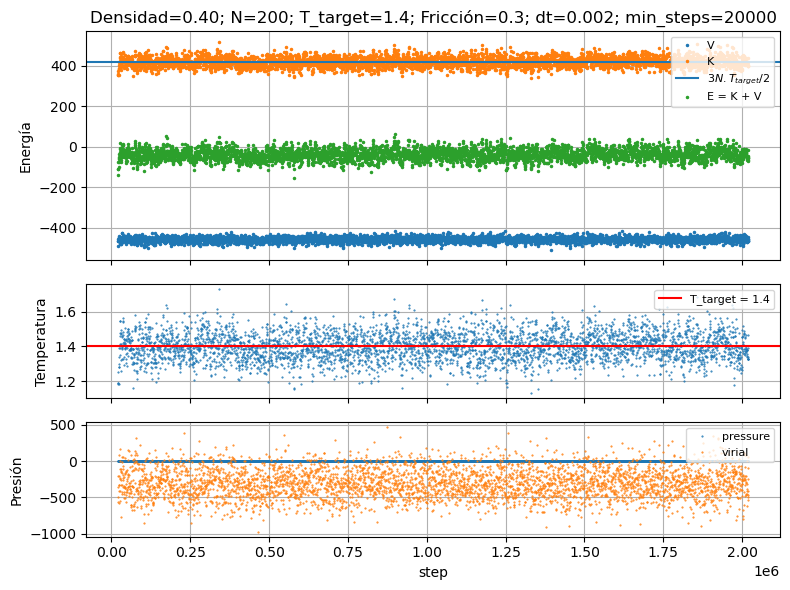

In [7]:
import numpy as np
import matplotlib.pyplot as plt
sim = sims[1]
sim_path = "simulaciones/"+sim
cfg = read_config(path="simulaciones/"+sim+"/config.txt")
N = cfg["N"]
L = cfg["L"]
densidad = N/(L**3)
T_target = cfg["T_target"]
equil = np.loadtxt(sim_path+"/mediciones.dat")
index, K, V, E, T, P, Vir = equil.T

fig, axs = plt.subplots(3,1, figsize=(8,6), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})
plt.subplots_adjust(wspace=0)
axs[0].set_title(f"Densidad={densidad:.2f}; N={N}; T_target={T_target}; Fricción={cfg["gamma"]}; dt={cfg["dt"]}; min_steps={cfg["N_minE"]}")


axs[0].plot(index, V,  ".", ms=3, label = "V")
axs[0].plot(index, K,  ".",ms=3, label = "K")
axs[0].axhline(3*N*T_target/2, label = r"$3N.T_{target}/2$")
axs[0].plot(index, E, ".", ms=3, label = "E = K + V")
axs[1].plot(index, T, ".", ms=1)
axs[2].plot(index, P, ".", ms=1, label="pressure")
axs[2].plot(index, Vir, ".", ms=1, label="virial")

axs[2].set_xlabel("step")
axs[0].set_ylabel("Energía")
axs[1].set_ylabel("Temperatura")
axs[1].axhline(T_target, c="r", label = f"T_target = {T_target}")
axs[2].set_ylabel("Presión")
axs[0].legend(loc="upper right", fontsize=8)
#axs[0].set_ylim(-20, 600)
#axs[1].set_ylim(0, 10)
#axs[2].set_ylim(-2, 5)
axs[2].legend(loc="upper right", fontsize=8)
axs[1].legend(loc="upper right", fontsize=8)
#axs[0].set_xlim(1e6, 1.1e6)
for ax in axs[:-1]:
    ax.label_outer()
axs[0].grid()
axs[1].grid()
axs[2].grid()
plt.tight_layout()
plt.savefig(f"N{N}_T{T_target}_dens{densidad:2f}_g{cfg["gamma"]}_dt{cfg["dt"]}_minE{cfg["N_minE"]}.png")

In [4]:
cfg

{'N': 200,
 'L': 5.848035,
 'sigma': 1.0,
 'eps': 1.0,
 'm': 1.0,
 'dc': 2.5,
 'dt': 0.002,
 'gamma': 0.3,
 'kB': 1.0,
 'T_target': 1.1,
 'N_minE': 0,
 'N_eq': 3000000,
 'N_steps': 3000000,
 'Vc': -0.016317,
 'rho': 1.0}

In [127]:
points = []
for sim in sims:
    sim_path = "simulaciones/" + sim
    cfg = read_config(path=sim_path + "/config.txt")
    N = int(cfg["N"])
    L = float(cfg["L"])
    dens = N / (L**3)
    points.append((dens, float(cfg["T_target"])))
points

[(0.40000003928549965, 1.4),
 (0.5700000698225994, 1.1),
 (0.40000003928549965, 1.1),
 (0.010000000183408476, 1.1),
 (0.22000000419102264, 1.1),
 (0.780000103195399, 1.1),
 (0.40000003928549965, 1.33),
 (0.40000003928549965, 0.98),
 (0.40000003928549965, 1.26),
 (0.49999999944641615, 1.1),
 (0.2999999636698282, 1.1),
 (0.2999999636698282, 1.4),
 (0.40000003928549965, 1.05),
 (0.010000000183408476, 1.1),
 (0.40000003928549965, 0.7),
 (0.42999993537635517, 1.1),
 (0.40000003928549965, 0.77),
 (0.6400000117381425, 1.1),
 (0.2899999659105203, 1.1),
 (0.40000003928549965, 1.12),
 (0.10000001188047708, 1.1),
 (0.0009999999879065707, 1.1),
 (0.8000000950438166, 1.1),
 (1.0000002444030025, 1.1),
 (0.40000003928549965, 0.84),
 (1.0000002444030025, 1.1),
 (0.359999988758837, 1.1),
 (0.8999998407628035, 1.1),
 (0.40000003928549965, 0.91),
 (0.40000003928549965, 1.19),
 (0.8999998407628035, 1.1),
 (0.7100001521144682, 1.1)]

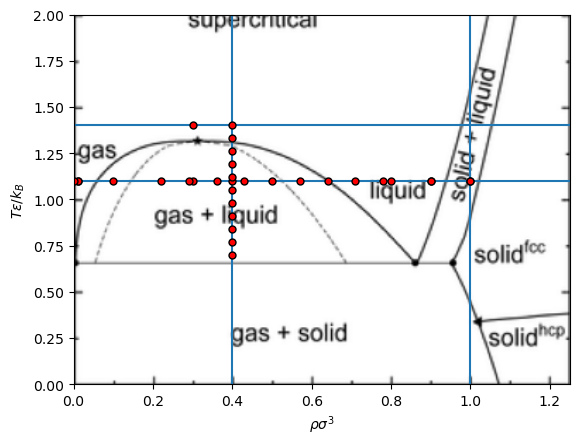

In [ ]:

import matplotlib.pyplot as plt

img = plt.imread('diagrama_fases_LJ.png')
fig, ax = plt.subplots()
ax.imshow(img, extent=[-0.003, 1.257, -0.022, 2.5], aspect="auto")

ax.axhline(1.1, label = "T = 1.1")
ax.axhline(1.4,  label = "T = 1.4")
ax.axvline(0.4,  label = "Densidad = 0.4")
ax.axvline(1,  label = "Densidad = 1")

for x, y in points:
    ax.plot(x, y, 'ro', markersize=5, markeredgecolor='black')  

ax.set_xlabel(r'$\rho \sigma^3$')
ax.set_ylabel(r'$T \epsilon / k_B$')
ax.set_xlim(0, 1.25)
ax.set_ylim(0, 2)
plt.savefig('diagrama_con_puntos.png', dpi=300)
plt.show()

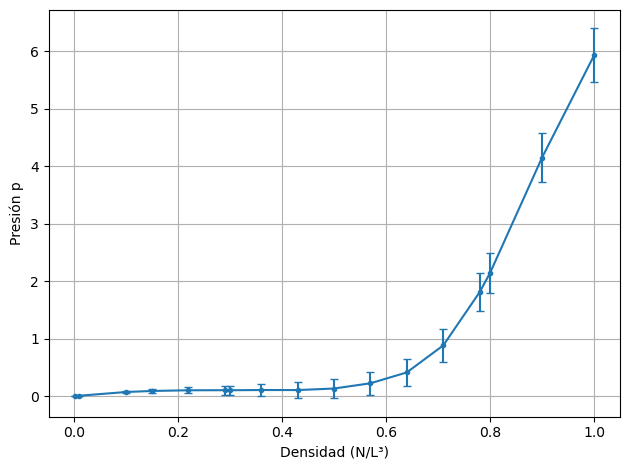

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


mean_p_5e5 = []; sigma_p_5e5 = []; dens_5e5 = []
sims = [file for file in os.listdir("simulaciones") if "COMPLETE" in file and not "SINminE" in file and not ".png" in file and not "sim" in file and not "final" in file]
for sim in sims:
    sim_path = "simulaciones/" + sim
    if "config.txt" in os.listdir(sim_path):
        cfg = read_config(path=sim_path + "/config.txt")

        if cfg["T_target"] == 1.1:
            N = int(cfg["N"])
            L = float(cfg["L"])
            dens = N / (L**3)
            mp, sp = np.loadtxt(sim_path + "/summary.dat")
            mean_p_5e5.append(mp)
            sigma_p_5e5.append(sp)
            dens_5e5.append(dens)

#  Ordenar por densidad 
def sort_by_density(dens_list, mean_list, sigma_list):
    idx = np.argsort(dens_list)
    return (np.array(dens_list)[idx],
            np.array(mean_list)[idx],
            np.array(sigma_list)[idx])

dens_5e5, mean_p_5e5, sigma_p_5e5 = sort_by_density(dens_5e5, mean_p_5e5, sigma_p_5e5)


plt.figure()
plt.errorbar(dens_5e5, mean_p_5e5, yerr=sigma_p_5e5,
             fmt='.-', capsize=3)


plt.xlabel("Densidad (N/L³)")
plt.ylabel("Presión p")
plt.grid()

plt.tight_layout()
plt.savefig("Pdens_COMP.png") # con 1e6 pasos de equilibración


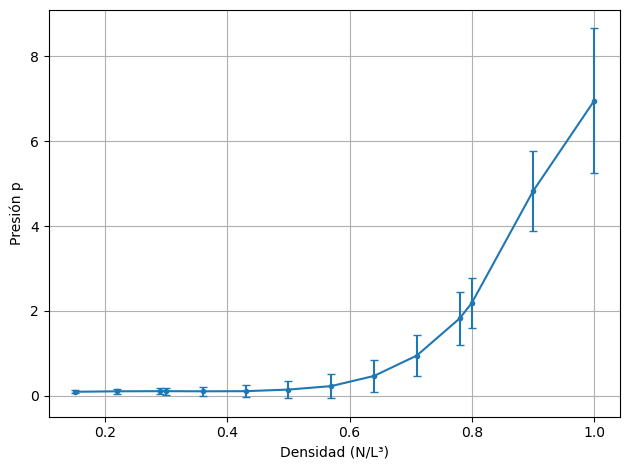

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sims = [file for file in os.listdir("simulaciones") if not "COMPLETE" in file and not "SINminE" in file and not ".png" in file and not "sim" in file and not "final" in file]
mean_p_5e5 = []; sigma_p_5e5 = []; dens_5e5 = []

for sim in sims:
    sim_path = "simulaciones/" + sim
    if "config.txt" in os.listdir(sim_path):
        cfg = read_config(path=sim_path + "/config.txt")

        if cfg["T_target"] == 1.1:
            N = int(cfg["N"])
            L = float(cfg["L"])
            dens = N / (L**3)
            mp, sp = np.loadtxt(sim_path + "/summary.dat")
            mean_p_5e5.append(mp)
            sigma_p_5e5.append(sp)
            dens_5e5.append(dens)

#  Ordenar por densidad 
def sort_by_density(dens_list, mean_list, sigma_list):
    idx = np.argsort(dens_list)
    return (np.array(dens_list)[idx],
            np.array(mean_list)[idx],
            np.array(sigma_list)[idx])

dens_5e5, mean_p_5e5, sigma_p_5e5 = sort_by_density(dens_5e5, mean_p_5e5, sigma_p_5e5)


plt.figure()
plt.errorbar(dens_5e5, mean_p_5e5, yerr=sigma_p_5e5,
             fmt='.-', capsize=3)


plt.xlabel("Densidad (N/L³)")
plt.ylabel("Presión p")
plt.grid()

plt.tight_layout()
plt.savefig("P_vs_dens.png") # con del orden de 30000 pasos de equilibración


In [ ]:
sims =[file for file in os.listdir("simulaciones") if not "COMPLETE" in file and not "SINminE" in file and not ".png" in file and not "sim" in file and not "final" in file]

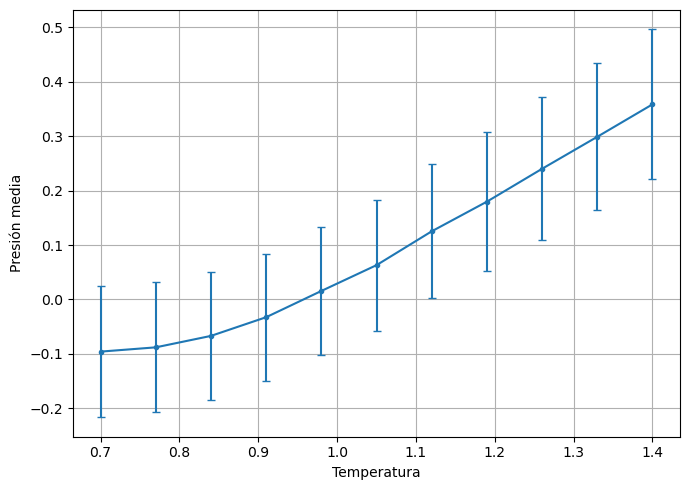

In [24]:
import numpy as np
import matplotlib.pyplot as plt

T_target = []; mean_p = []; sigma_p = []
sims = [file for file in os.listdir("simulaciones") if not "COMPLETE" in file and not "SINminE" in file and not ".png" in file and not "sim" in file and not "final" in file]
for sim in sims:
    sim_path = f"simulaciones/{sim}"
    cfg = read_config(path=sim_path + "/config.txt")

    T = float(cfg["T_target"])

    mp, sp = np.loadtxt(sim_path + "/summary.dat")
    N = int(cfg["N"])
    L = float(cfg["L"])
    dens = N / (L**3)

    if abs(dens-0.4) < 1e-5:
        T_target.append(T)
        mean_p.append(mp)
        sigma_p.append(sp)

def sort_by_T(T_list, mean_list, sigma_list):
    idx = np.argsort(T_list)
    return (np.array(T_list)[idx],
            np.array(mean_list)[idx],
            np.array(sigma_list)[idx])

T_target, mean_p, sigma_p = sort_by_T(T_target, mean_p, sigma_p)

plt.figure(figsize=(7,5))
plt.errorbar(T_target, mean_p, yerr=sigma_p,
             fmt='.-', capsize=3)
plt.xlabel("Temperatura")
plt.ylabel("Presión media")
plt.grid(True)
plt.tight_layout()
plt.savefig("p_vs_T.png")


In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import rdf
import matplotlib.pyplot as plt
import numpy as np
sims = [i for i in os.listdir("simulaciones") if i.startswith("N")]
for sim in sims:
    sim_path = f"simulaciones/{sim}"
    cfg = read_config(path=f"{sim_path}/config.txt")
    L = float(cfg["L"])
    sigma = float(cfg.get("sigma", 1.0))  
    vtf_to_xyz(f"{sim_path}/traj.vtf", f"{sim_path}/traj.xyz")

    u = mda.Universe(f"{sim_path}/traj.xyz")
    u.dimensions = np.array([L, L, L, 90, 90, 90]) 

    sel = u.select_atoms("all")
    rdf_obj = rdf.InterRDF(sel, sel, nbins=100, range=(1e-4, L/2))
    rdf_obj.run()

    plt.plot(rdf_obj.bins / sigma, rdf_obj.rdf, label=sim)
    plt.xlabel(r"$r / \sigma$")
    plt.ylabel("g(r)")
    plt.title(f"Función de distribución radial")
    plt.grid(True)
    #plt.savefig(f"{sim_path}/g_r.png", dpi=200)
    #plt.close()
    

N200_T1.10_rho0.01
N200_T1.10_rho0.10
N200_T1.10_rho0.40_dt0.002
N200_T1.10_rho0.90
N200_T1.10_rho1.00


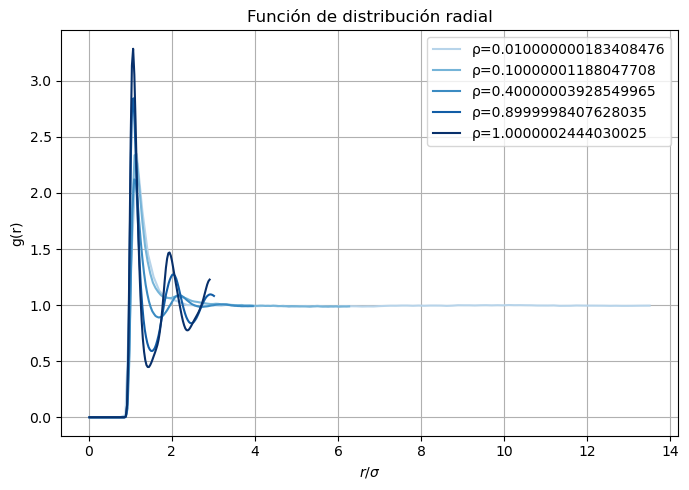

In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import rdf
from matplotlib import colormaps


densidades = []
for sim in sims:
    cfg = read_config(f"simulaciones/{sim}/config.txt")
    densidades.append(float(cfg["N"])/(float(cfg["L"])**3))

sims_sorted = [s for _, s in sorted(zip(densidades, sims))]
dens_sorted = sorted(densidades)

cmap = colormaps["Blues"]
colors = [cmap(0.3 + 0.7 * i / (len(sims_sorted) - 1)) for i in range(len(sims_sorted))]


plt.figure(figsize=(7, 5))
for sim, rho, color in zip(sims_sorted, dens_sorted, colors):
    sim_path = f"simulaciones/{sim}"
    cfg = read_config(f"{sim_path}/config.txt")
    if round(d,3) in [0.3, 0.8]:
        print(sim)
        
        L = float(cfg["L"])
        sigma = float(cfg.get("sigma", 1.0))
        if "gr.txt" not in os.listdir(sim_path):

            vtf_to_xyz(f"{sim_path}/traj.vtf", f"{sim_path}/traj.xyz")

            u = mda.Universe(f"{sim_path}/traj.xyz")
            u.dimensions = np.array([L, L, L, 90, 90, 90])

            sel = u.select_atoms("all")
            rdf_obj = rdf.InterRDF(sel, sel, nbins=100, range=(1e-4, L/2))
            rdf_obj.run()

            np.savetxt(f"{sim_path}/gr.txt",
                    np.column_stack((rdf_obj.results.bins / sigma, rdf_obj.rdf)),
                    header="r/sigma   g(r)", fmt="%.6f")
            r = rdf_obj.bins / sigma
            g = rdf_obj.results.rdf
        else:
            r, g = np.loadtxt(f"{sim_path}/gr.txt").T
            

        plt.plot(r, g, label=f"ρ={rho}", color=color)

plt.xlabel(r"$r / \sigma$")
plt.ylabel("g(r)")
plt.title("Función de distribución radial")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gr_all.png", dpi=300)
plt.show()



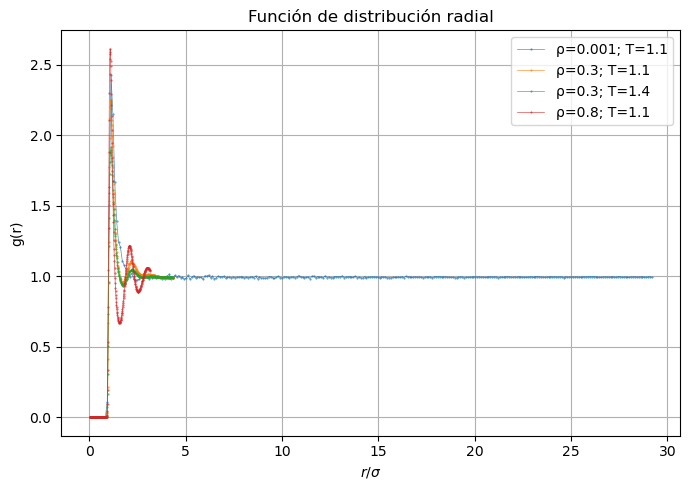

In [18]:

import os
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import rdf
from matplotlib import colormaps



sims = [i for i in os.listdir("simulaciones") if i.startswith("COMP")]

temperatures = []
densidades = []
for sim in sims:
    cfg = read_config(f"simulaciones/{sim}/config.txt")
    densidades.append(float(cfg["N"])/(float(cfg["L"])**3))
    temperatures.append(cfg["T_target"])

sims_sorted = [s for _, s in sorted(zip(densidades, sims))]
dens_sorted = sorted(densidades)


cmap = colormaps["Blues"]
colors = [cmap(0.5 + 0.7 * i / (len(sims_sorted) - 1)) for i in range(len(sims_sorted))]


plt.figure(figsize=(7, 5))
for sim, rho, temp, color in zip(sims_sorted, dens_sorted, temperatures, colors):
    sim_path = f"simulaciones/{sim}"
    cfg = read_config(f"{sim_path}/config.txt")
    if (cfg["T_target"], round(rho,3)) in [(1.1,0.3),(1.4,0.3), (1.1,0.8), (1.1,0.001)]:
        
        L = float(cfg["L"])
        sigma = float(cfg.get("sigma", 1.0))
        if "gr.txt" not in os.listdir(sim_path):
            if not f"{sim_path}/traj.xyz" in os.listdir(sim_path):
                vtf_to_xyz(f"{sim_path}/traj.vtf", f"{sim_path}/traj.xyz")

            u = mda.Universe(f"{sim_path}/traj.xyz")
            u.dimensions = np.array([L, L, L, 90, 90, 90])

            sel = u.select_atoms("all")
            rdf_obj = rdf.InterRDF(sel, sel, nbins=300, range=(1e-4, L/2))
            rdf_obj.run()

            np.savetxt(f"{sim_path}/gr.txt",
                    np.column_stack((rdf_obj.results.bins / sigma, rdf_obj.rdf)),
                    header="r/sigma   g(r)", fmt="%.6f")
            r = rdf_obj.bins / sigma
            g = rdf_obj.results.rdf
        else:
            r, g = np.loadtxt(f"{sim_path}/gr.txt").T

        plt.plot(r, g, ".-", lw=0.5, ms=1, alpha=0.8, label=f"ρ={round(rho,3)}; T={cfg["T_target"]}") #color=color)

plt.xlabel(r"$r / \sigma$")
plt.ylabel("g(r)")
plt.title("Función de distribución radial")
plt.legend()
plt.grid(True)
#plt.xlim(0, 3)
#plt.ylim(0.8,1.2)
plt.tight_layout()

plt.savefig("gr_all_COMPLETE.png", dpi=300)
plt.show()



In [ ]:
r, g = np.loadtxt(f"simulaciones/{sims[2]}/gr.txt").T.shape



(2, 100)

Text(0, 0.5, 'Temperatura')

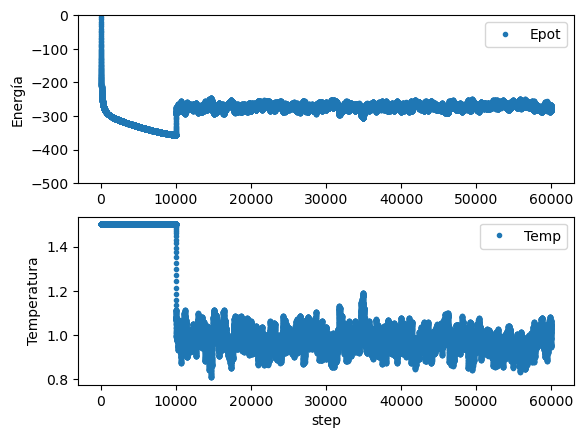

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


equil = np.loadtxt("equilibrio.dat")
index, Epot, T  = equil.T

fig, axs = plt.subplots(2,1)

axs[0].plot(index, Epot, ".", label = "Epot")
axs[1].plot(index, T, ".", label = "Temp")
axs[0].legend()
axs[0].set_ylim(-500, 0)

axs[1].legend()
axs[1].set_xlabel("step")
axs[0].set_ylabel("Energía")
axs[1].set_ylabel("Temperatura")